In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

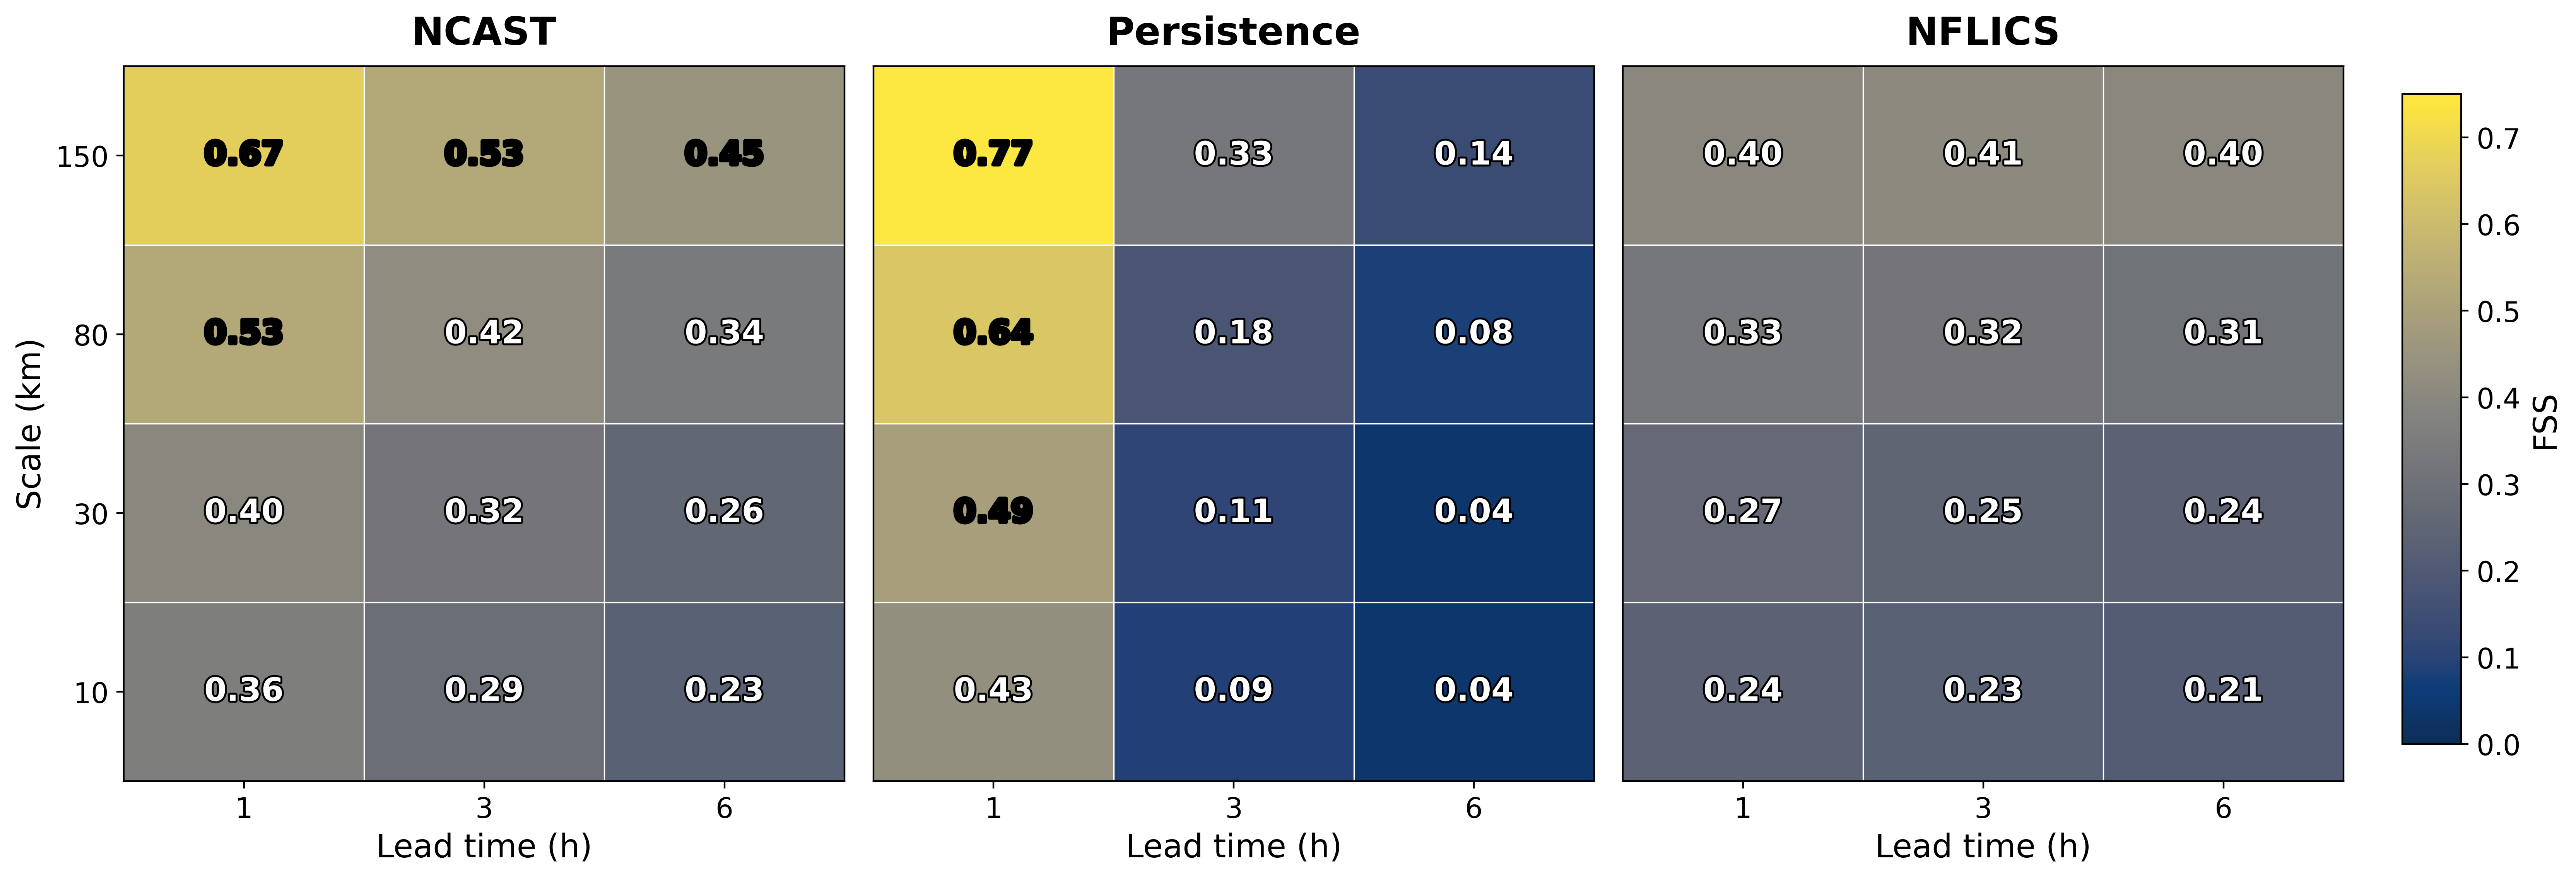

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

df = pd.read_csv("fss_comparison.csv")

models = ["NCAST", "Persistence", "NFLICS"]
scales = [150, 80, 30, 10]
leads = [1, 3, 6]

fig, axes = plt.subplots(1, 3, figsize=(19, 6), dpi=400)
plt.subplots_adjust(wspace=0.04)

vmin, vmax = 0.0, 0.75
cmap = "cividis"

for idx, (ax, model) in enumerate(zip(axes, models)):
    mat = np.zeros((len(scales), len(leads)))

    for i, s in enumerate(scales):
        for j, l in enumerate(leads):
            mat[i, j] = df[
                (df.model == model)
                & (df.scale_km == s)
                & (df.lead_time_h == l)
            ].fss.values[0]

    im = ax.imshow(
        mat,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
        alpha=0.95,
    )

    ax.set_title(model, fontsize=18, fontweight="bold", pad=10)
    ax.set_xlabel("Lead time (h)", fontsize=15)

    ax.set_xticks(range(len(leads)))
    ax.set_xticklabels(leads, fontsize=13)

    if idx == 0:
        ax.set_yticks(range(len(scales)))
        ax.set_yticklabels(scales, fontsize=13)
        ax.set_ylabel("Scale (km)", fontsize=15)
    else:
        ax.set_yticks([])

    ax.set_xticks(np.arange(-0.5, len(leads), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(scales), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(len(scales)):
        for j in range(len(leads)):
            v = mat[i, j]
            txt = ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=15,
                fontweight="bold",
                color="white" if v < 0.45 else "black",
            )
            txt.set_path_effects([
                pe.withStroke(linewidth=1.8, foreground="black")
            ])

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label("FSS", fontsize=15)
cbar.ax.tick_params(labelsize=13)

plt.show()


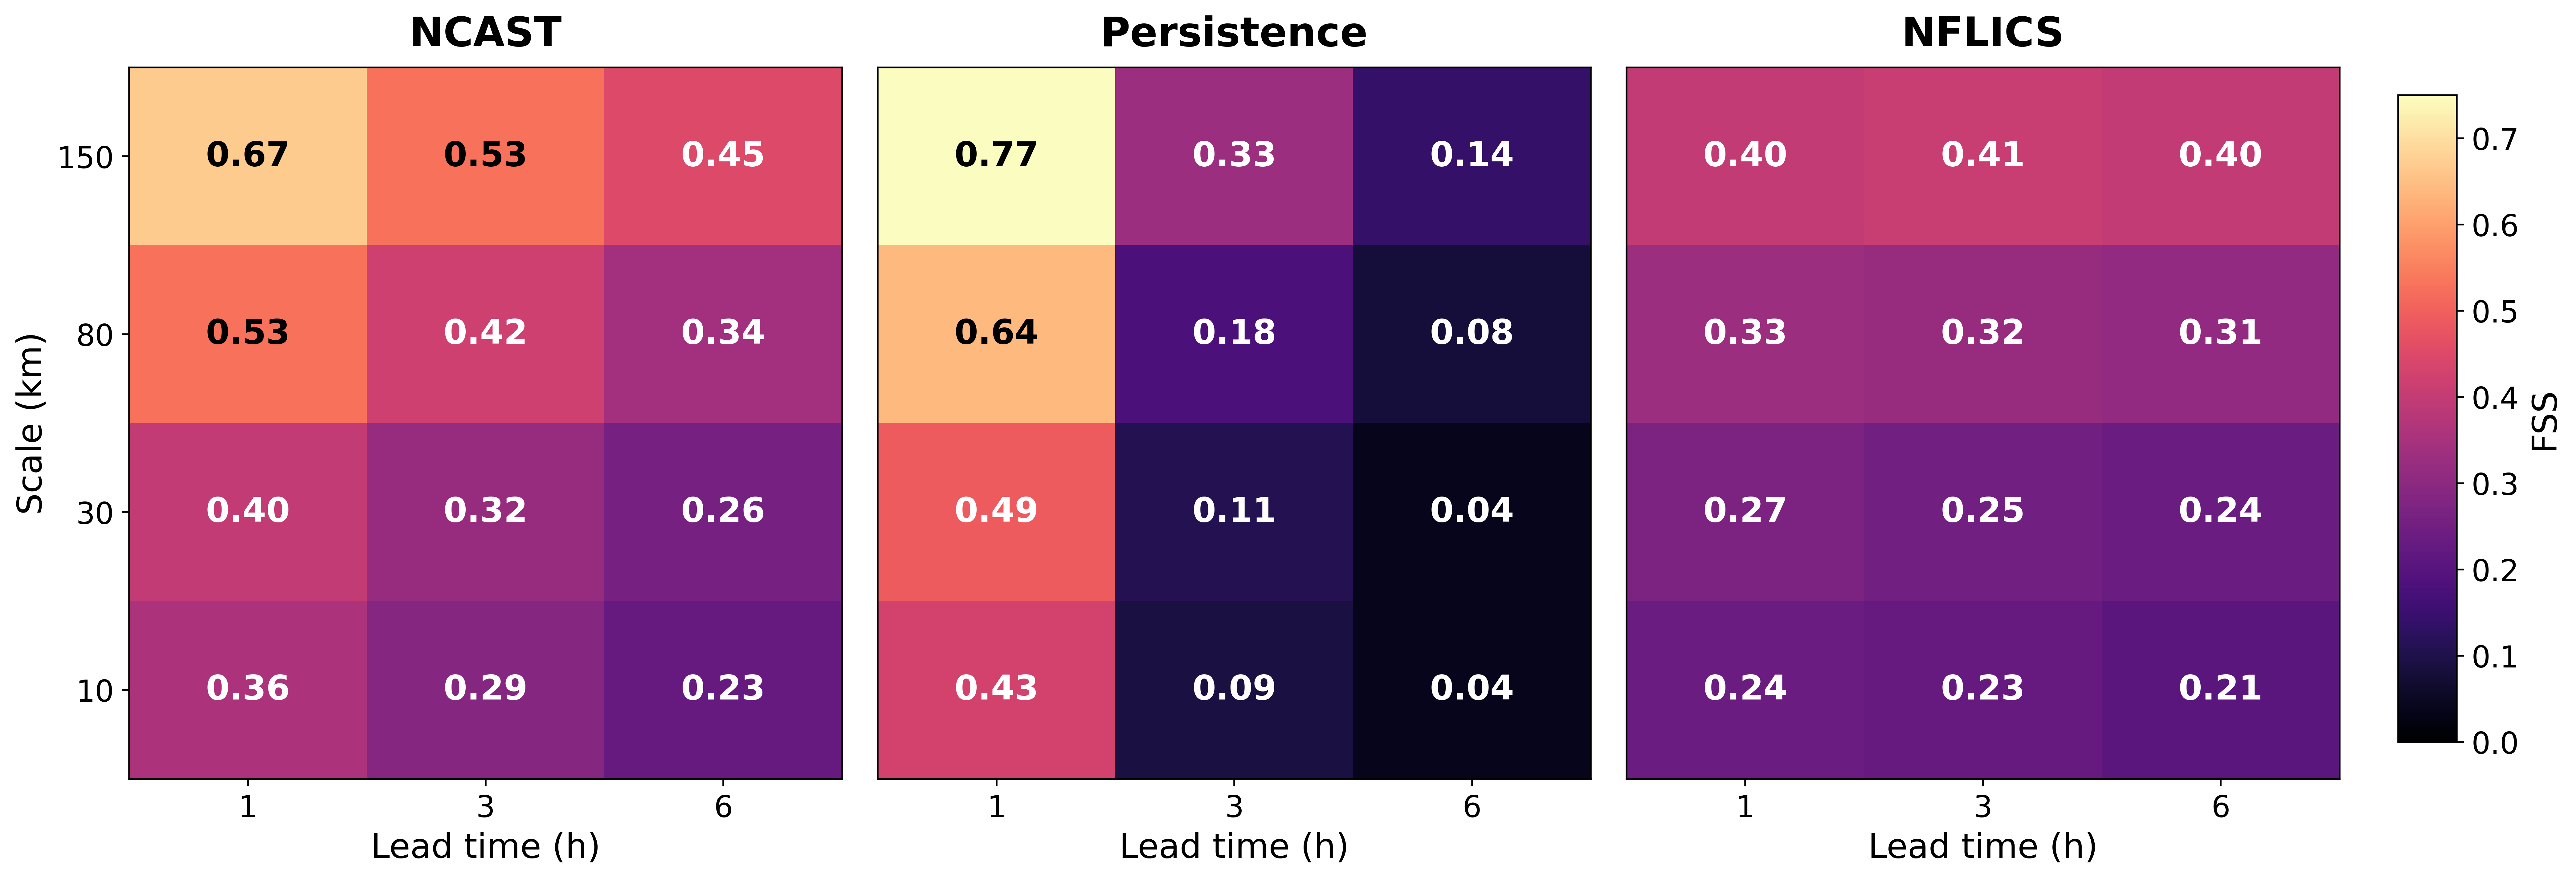

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("fss_comparison.csv")

models = ["NCAST", "Persistence", "NFLICS"]
scales = [150, 80, 30, 10]
leads = [1, 3, 6]

fig, axes = plt.subplots(1, 3, figsize=(19, 6), dpi=500)
plt.subplots_adjust(wspace=0.05)

vmin, vmax = 0.0, 0.75
cmap = "magma"

for idx, (ax, model) in enumerate(zip(axes, models)):
    mat = np.zeros((len(scales), len(leads)))

    for i, s in enumerate(scales):
        for j, l in enumerate(leads):
            mat[i, j] = df[
                (df.model == model)
                & (df.scale_km == s)
                & (df.lead_time_h == l)
            ].fss.values[0]

    im = ax.imshow(
        mat,
        vmin=vmin,
        vmax=vmax,
        cmap=cmap,
        aspect="auto",
    )

    ax.set_title(model, fontsize=19, fontweight="bold", pad=10)
    ax.set_xlabel("Lead time (h)", fontsize=16)

    ax.set_xticks(range(len(leads)))
    ax.set_xticklabels(leads, fontsize=14)

    if idx == 0:
        ax.set_yticks(range(len(scales)))
        ax.set_yticklabels(scales, fontsize=14)
        ax.set_ylabel("Scale (km)", fontsize=16)
    else:
        ax.set_yticks([])

    for i in range(len(scales)):
        for j in range(len(leads)):
            v = mat[i, j]
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color="white" if v < 0.5 else "black",
            )

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label("FSS", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.show()


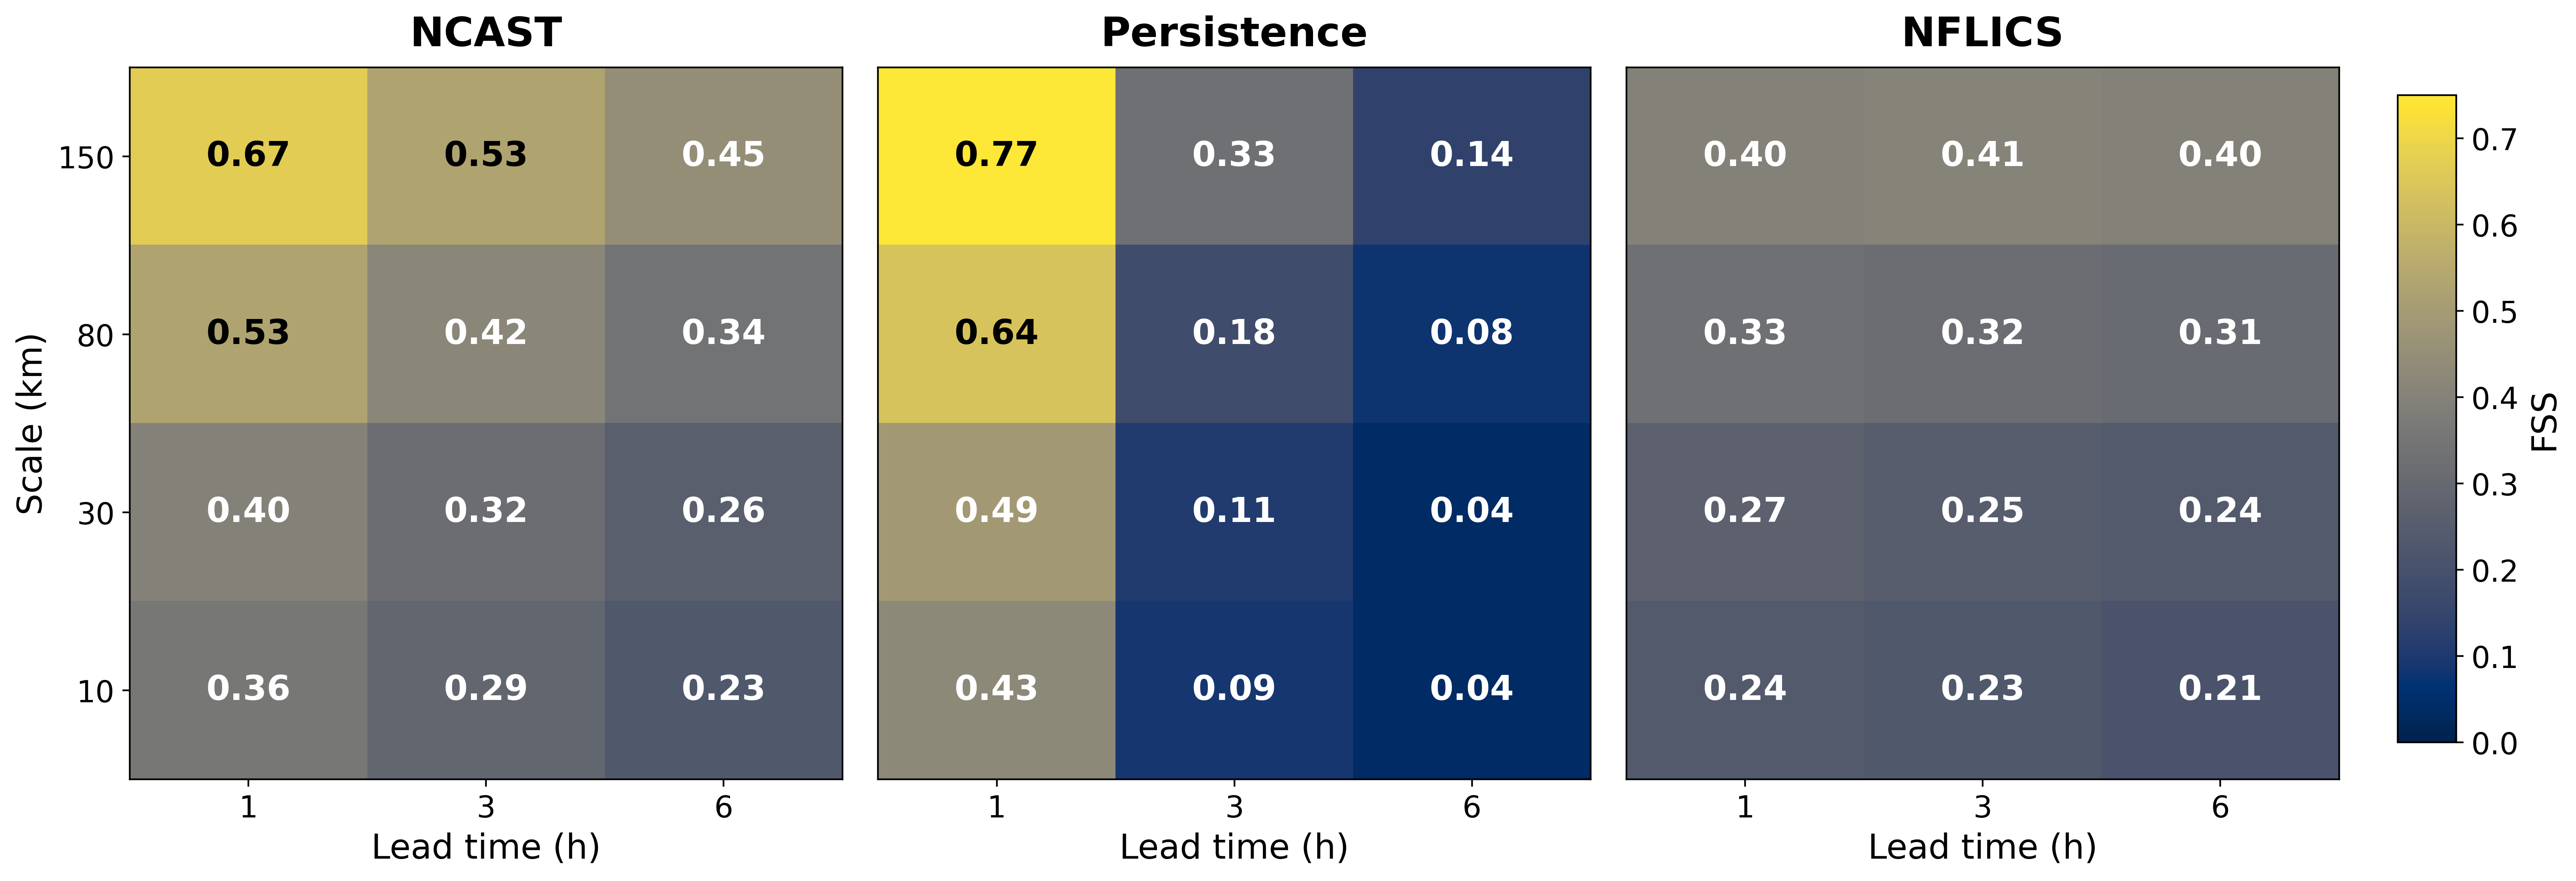

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

df = pd.read_csv("fss_comparison.csv")

models = ["NCAST", "Persistence", "NFLICS"]
scales = [150, 80, 30, 10]
leads = [1, 3, 6]

fig, axes = plt.subplots(1, 3, figsize=(19, 6), dpi=400)
plt.subplots_adjust(wspace=0.05)

vmin, vmax = 0.0, 0.75
cmap = plt.colormaps["cividis"]
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for idx, (ax, model) in enumerate(zip(axes, models)):
    mat = np.zeros((len(scales), len(leads)))

    for i, s in enumerate(scales):
        for j, l in enumerate(leads):
            mat[i, j] = df[
                (df.model == model)
                & (df.scale_km == s)
                & (df.lead_time_h == l)
            ].fss.values[0]

    im = ax.imshow(
        mat,
        cmap=cmap,
        norm=norm,
        aspect="auto",
    )

    ax.set_title(model, fontsize=19, fontweight="bold", pad=10)
    ax.set_xlabel("Lead time (h)", fontsize=16)

    ax.set_xticks(range(len(leads)))
    ax.set_xticklabels(leads, fontsize=14)

    if idx == 0:
        ax.set_yticks(range(len(scales)))
        ax.set_yticklabels(scales, fontsize=14)
        ax.set_ylabel("Scale (km)", fontsize=16)
    else:
        ax.set_yticks([])

    for i in range(len(scales)):
        for j in range(len(leads)):
            v = mat[i, j]
            rgba = cmap(norm(v))
            luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            txt_colour = "black" if luminance > 0.6 else "white"

            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold",
                color=txt_colour,
            )

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = plt.colorbar(im, cax=cbar_ax)
cbar.set_label("FSS", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.show()


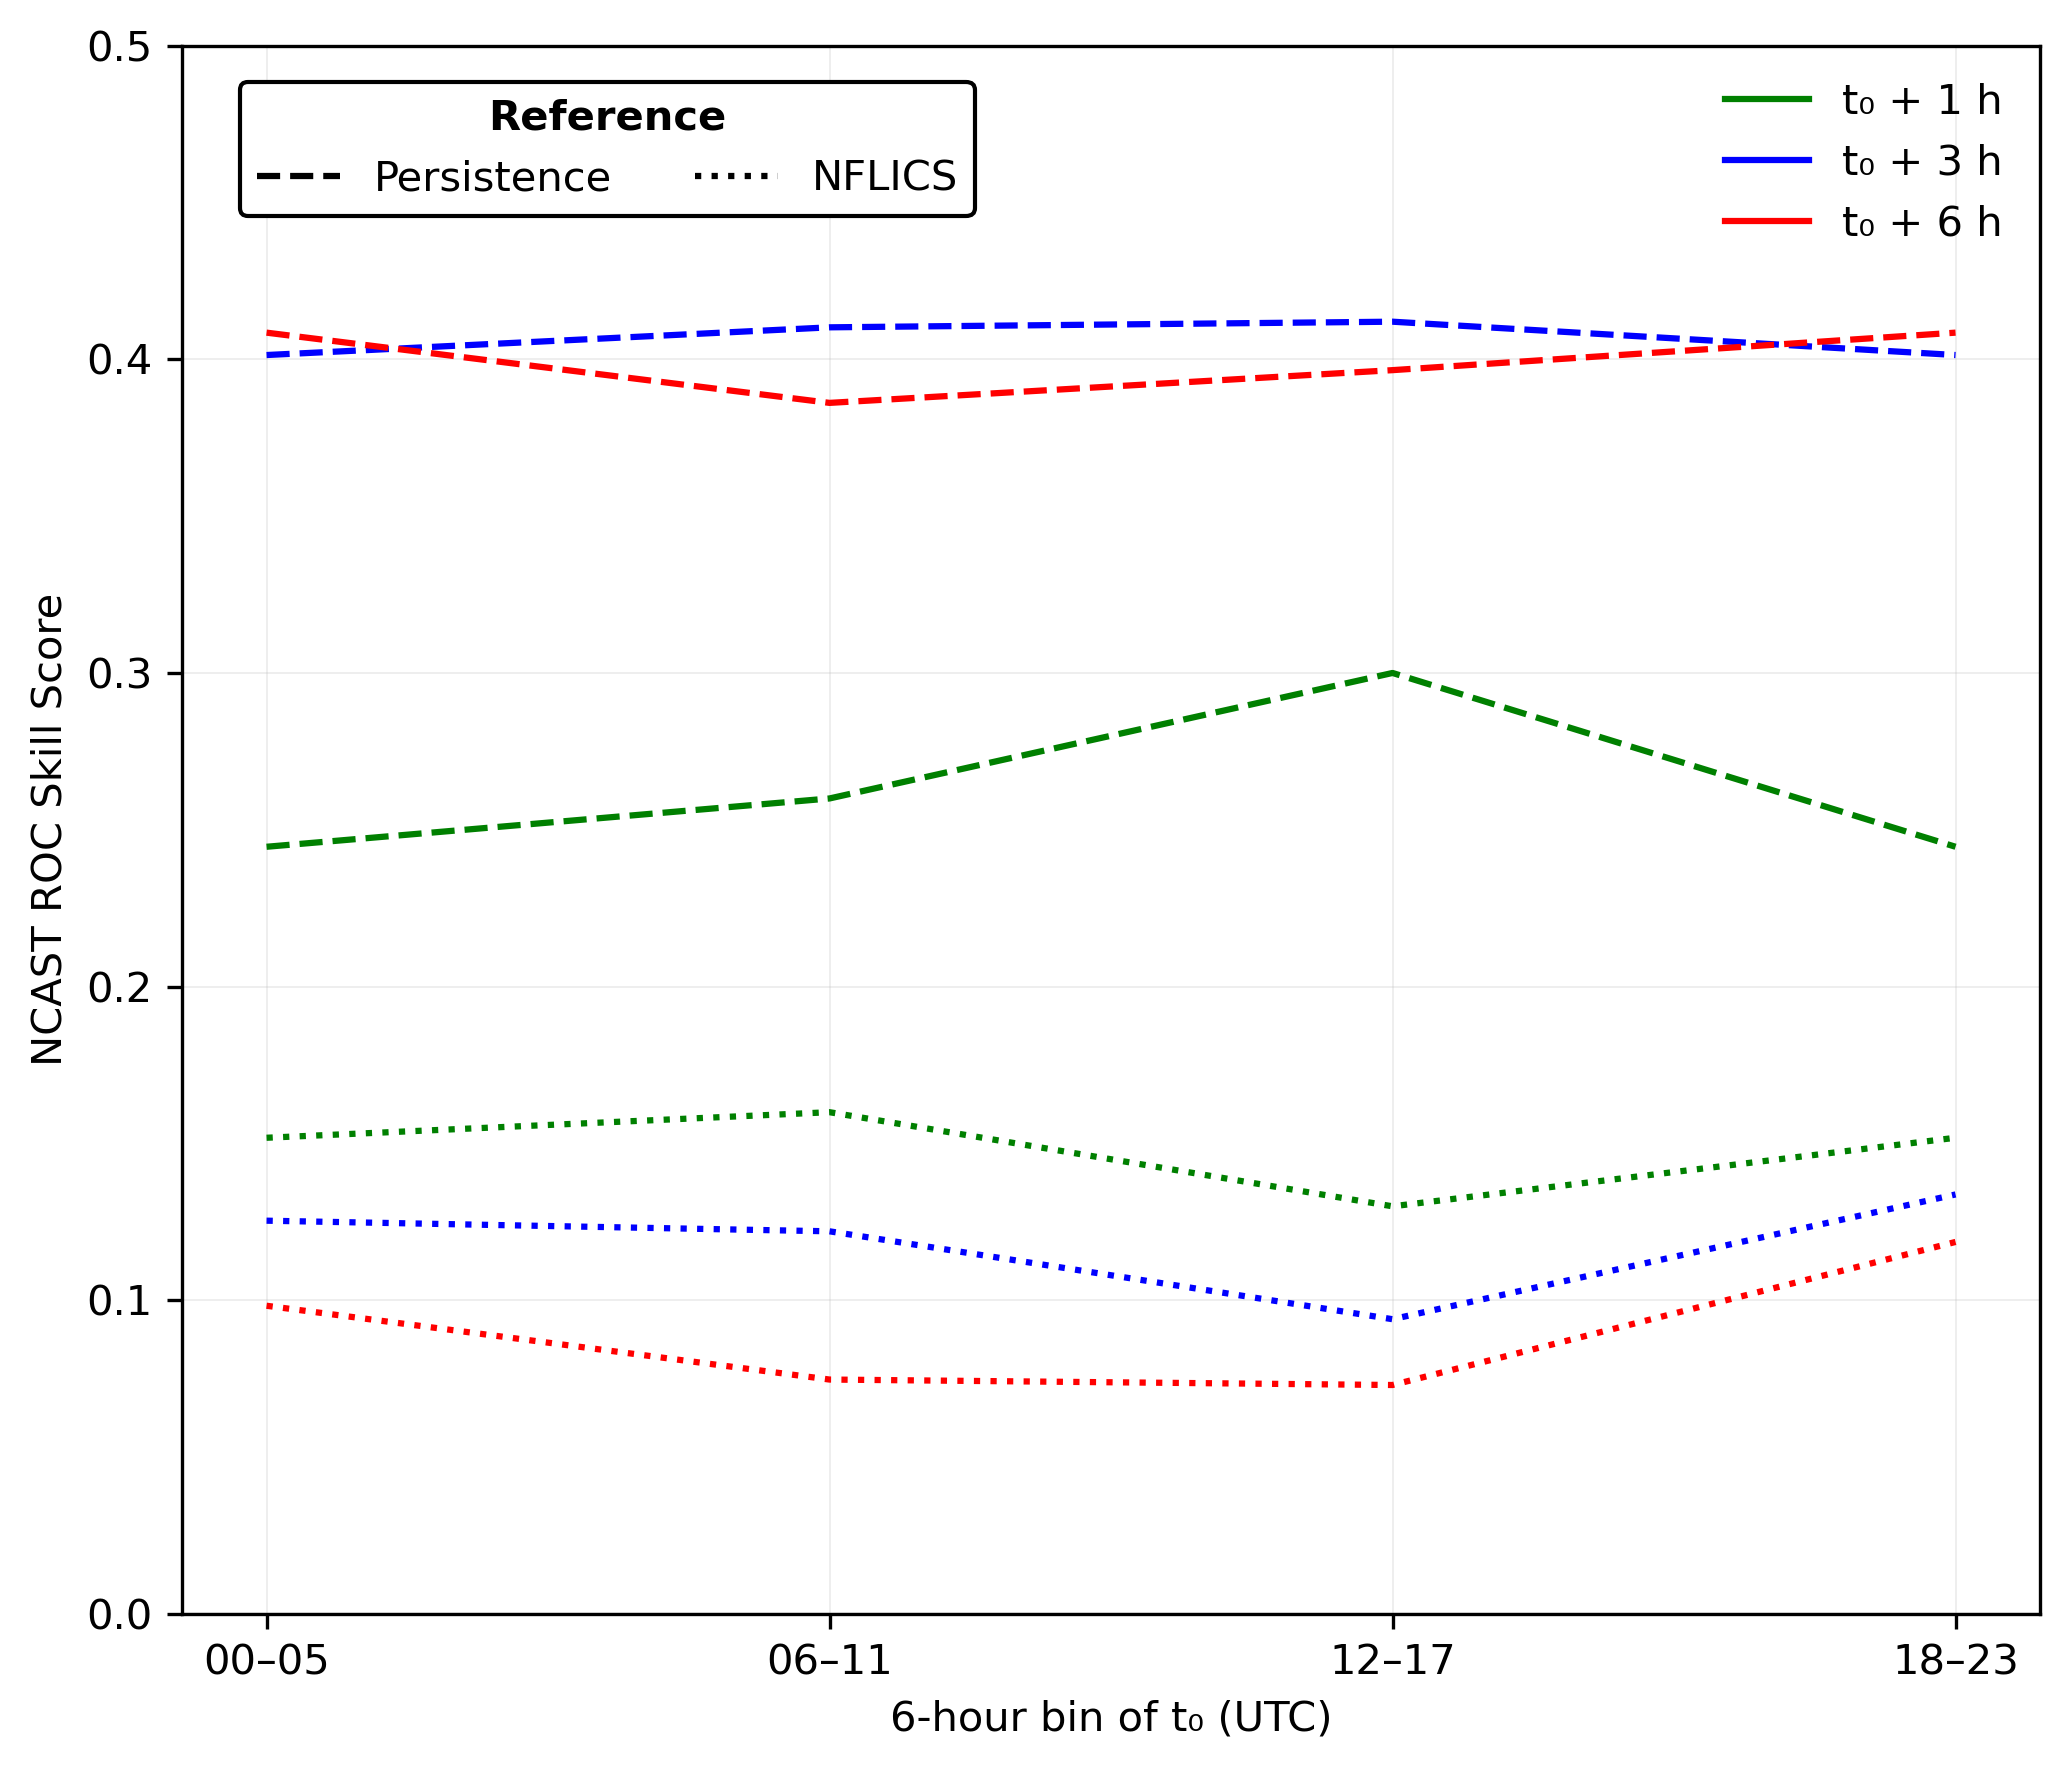

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

csv_path = "auc_hourly_values.csv"
df = pd.read_csv(csv_path)

bins = {
    "00–05": ["00", "01", "02", "03", "04", "05"],
    "06–11": ["06", "07", "08", "09", "10", "11"],
    "12–17": ["12", "13", "14", "15", "16", "17"],
    "18–23": ["18", "19", "20", "21", "22", "23"],
}

bin_labels = list(bins.keys())

nflics_linestyle = ":"
lead_times = ["1", "3", "6"]

colours = {
    "1": "green",
    "3": "blue",
    "6": "red",
}

def load_auc_from_csv(hour, lead):
    row = df[
        (df["hour"] == int(hour)) &
        (df["lead"] == int(lead))
    ]
    if row.empty:
        return np.nan, np.nan, np.nan

    return (
        row["auc_model"].values[0],
        row["auc_persistence"].values[0],
        row["auc_nflics"].values[0],
    )

auc_model_binned  = {L: [] for L in lead_times}
auc_pers_binned   = {L: [] for L in lead_times}
auc_nflics_binned = {L: [] for L in lead_times}

for L in lead_times:
    for label in bin_labels:
        hours = bins[label]

        vals_m, vals_p, vals_n = [], [], []
        for h in hours:
            am, ap, an = load_auc_from_csv(h, L)
            vals_m.append(am)
            vals_p.append(ap)
            vals_n.append(an)

        auc_model_binned[L].append(np.nanmean(vals_m))
        auc_pers_binned[L].append(np.nanmean(vals_p))
        auc_nflics_binned[L].append(np.nanmean(vals_n))

rocss_pers_binned   = {L: [] for L in lead_times}
rocss_nflics_binned = {L: [] for L in lead_times}

for L in lead_times:
    for am, ap, an in zip(
        auc_model_binned[L],
        auc_pers_binned[L],
        auc_nflics_binned[L],
    ):
        if np.isnan(am) or am == 0:
            rocss_pers_binned[L].append(np.nan)
            rocss_nflics_binned[L].append(np.nan)
            continue

        r_p = 1 - ap / am if not np.isnan(ap) else np.nan
        r_n = 1 - an / am if not np.isnan(an) else np.nan

        rocss_pers_binned[L].append(r_p)
        rocss_nflics_binned[L].append(r_n)

plt.figure(figsize=(7, 6), dpi=300)

for L in lead_times:
    c = colours[L]

    plt.plot(
        bin_labels,
        rocss_pers_binned[L],
        linestyle="--",
        color=c,
    )

    plt.plot(
        bin_labels,
        rocss_nflics_binned[L],
        linestyle=nflics_linestyle,
        color=c,
    )

plt.axhline(0, color="black", linewidth=0.5)

plt.xlabel("6-hour bin of t₀ (UTC)")
plt.ylabel("NCAST ROC Skill Score")
plt.grid(True, linewidth=0.1)

colour_handles = [
    Line2D([0], [0], color="green", linestyle="-", label="t₀ + 1 h"),
    Line2D([0], [0], color="blue",  linestyle="-", label="t₀ + 3 h"),
    Line2D([0], [0], color="red",   linestyle="-", label="t₀ + 6 h"),
]

first_legend = plt.legend(
    handles=colour_handles,
    loc="upper right",
    frameon=False,
)
plt.gca().add_artist(first_legend)

style_handles = [
    Line2D([0], [0], color="black", linestyle="--", label="Persistence"),
    Line2D([0], [0], color="black", linestyle=":",  label="NFLICS"),
]

leg = plt.legend(
    handles=style_handles,
    title="Reference",
    loc="upper left",
    bbox_to_anchor=(0.02, 0.99),
    frameon=True,
    framealpha=1.0,
    edgecolor="black",
    ncols=2,
)

leg.get_title().set_fontweight("bold")

plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()
